# Milestone 2: Data Cleaning & EDA Notebook

In [16]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

from mplsoccer import Pitch
# Load files
df_std = pd.read_csv("pl_standard_stats.csv")
df_shoot = pd.read_csv("pl_shooting_stats.csv")
df_misc = pd.read_csv("pl_misc_stats.csv")

# Clean column names
df_std.columns = df_std.columns.str.strip()
df_shoot.columns = df_shoot.columns.str.strip()
df_misc.columns = df_misc.columns.str.strip()

# Merge keys (safe version)
merge_cols = ['league', 'season', 'team', 'player', 'nation_', 'pos_', 'age_', 'born_']

# Keep only valid keys that exist in ALL datasets
merge_cols = [c for c in merge_cols if c in df_std.columns 
                                     and c in df_shoot.columns 
                                     and c in df_misc.columns]

# Merge (LEFT JOIN = prevents data loss)
df_all = df_std.merge(df_shoot, on=merge_cols, how='left')
df_all = df_all.merge(df_misc, on=merge_cols, how='left')

# Cleaning
if 'age_' in df_all.columns:
    df_all['age_numeric'] = df_all['age_'].astype(str).str.split('-').str[0]
    df_all['age_numeric'] = pd.to_numeric(df_all['age_numeric'], errors='coerce')

df_all = df_all.fillna(0)

# Save final dataset for Streamlit
df_all.to_csv("pl_master_clean.csv", index=False)

print("Pipeline ready:", len(df_all), "players")

Pipeline ready: 537 players


1) Goal Distribution

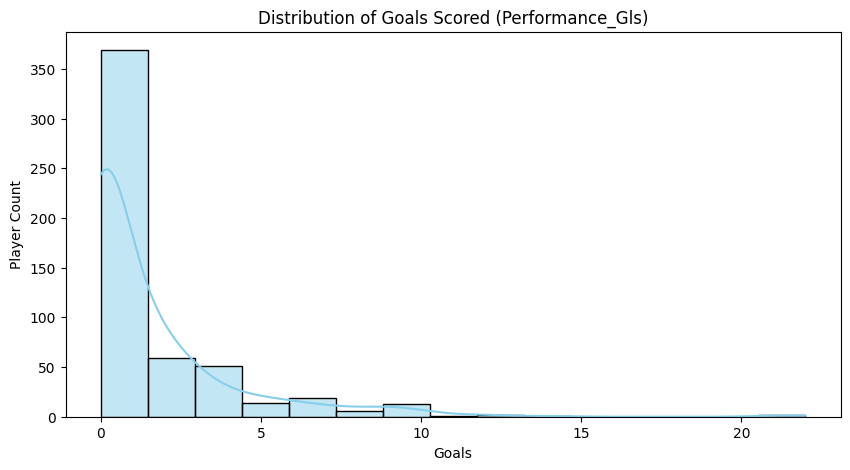

In [17]:
plt.figure(figsize=(10, 5))
sns.histplot(df_all['Performance_Gls'], bins=15, kde=True, color='skyblue')
plt.title("Distribution of Goals Scored (Performance_Gls)")
plt.xlabel("Goals")
plt.ylabel("Player Count")
plt.show()

2. Shot Volume vs Accuracy

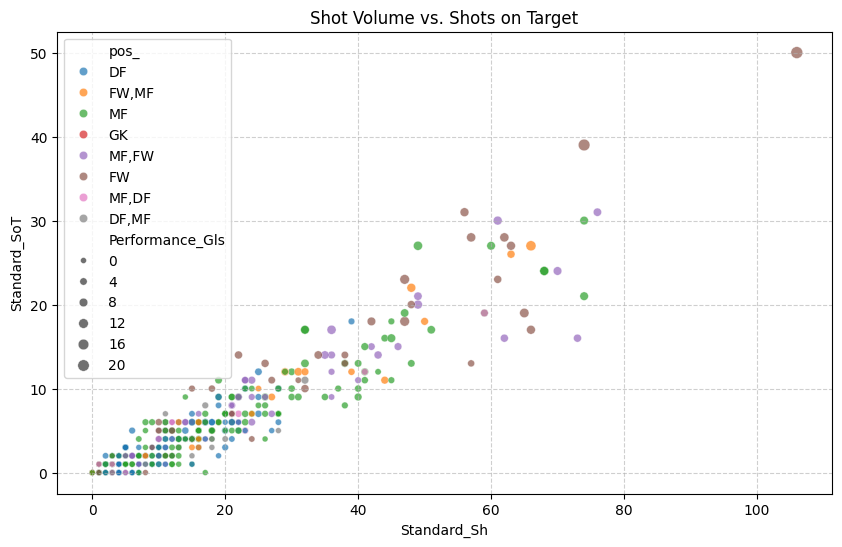

In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_all, x='Standard_Sh', y='Standard_SoT', size='Performance_Gls', hue='pos_', alpha=0.7)
plt.title("Shot Volume vs. Shots on Target")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

3. Defensive Action Intensity

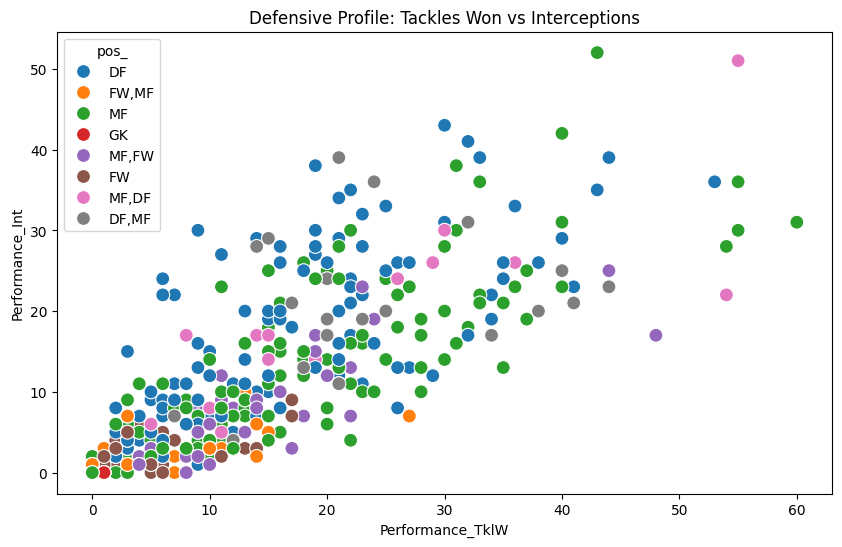

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_all, x='Performance_TklW', y='Performance_Int', hue='pos_', s=100)
plt.title("Defensive Profile: Tackles Won vs Interceptions")
plt.show()

4. Discipline Heatmap

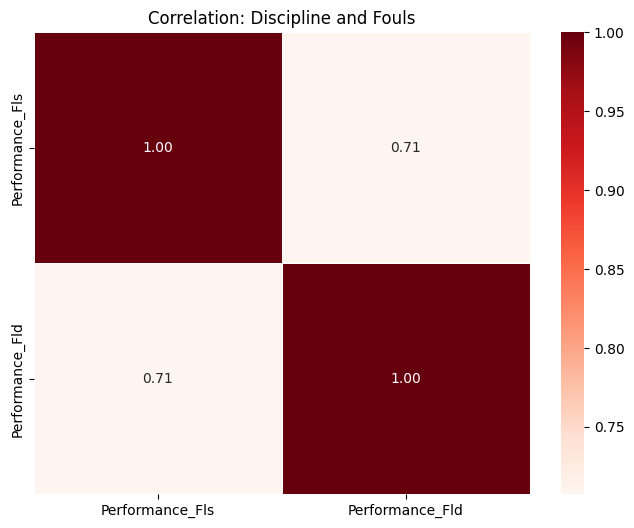

In [20]:
plt.figure(figsize=(8, 6))
discipline_cols = ['Performance_CrdY', 'Performance_CrdR', 'Performance_Fls', 'Performance_Fld']
valid_cols = [c for c in discipline_cols if c in df_all.columns]
data_for_corr = df_all[valid_cols].apply(pd.to_numeric, errors='coerce')
corr_matrix = data_for_corr.corr()
sns.heatmap(corr_matrix, annot=True, cmap='Reds', fmt=".2f", linewidths=0.5)
plt.title("Correlation: Discipline and Fouls")
plt.show()

5. Age vs. Playing Time

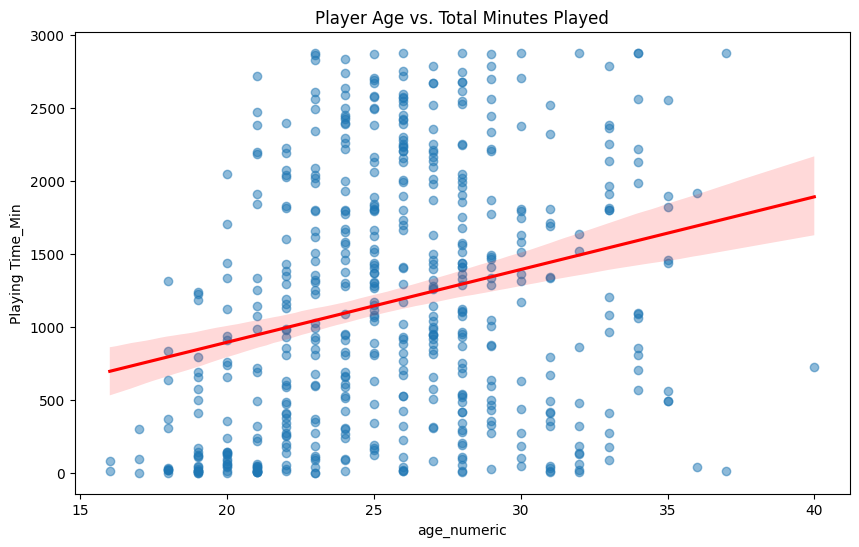

In [21]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df_all, x='age_numeric', y='Playing Time_Min', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title("Player Age vs. Total Minutes Played")
plt.show()

6. Top Offensive Contributors (Per 90)

/var/folders/k3/19cxn8h95xj4bsdswc1m3jf80000gn/T/ipykernel_19009/4122235489.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_creators, x='Per 90 Minutes_G+A', y='player', palette='viridis')


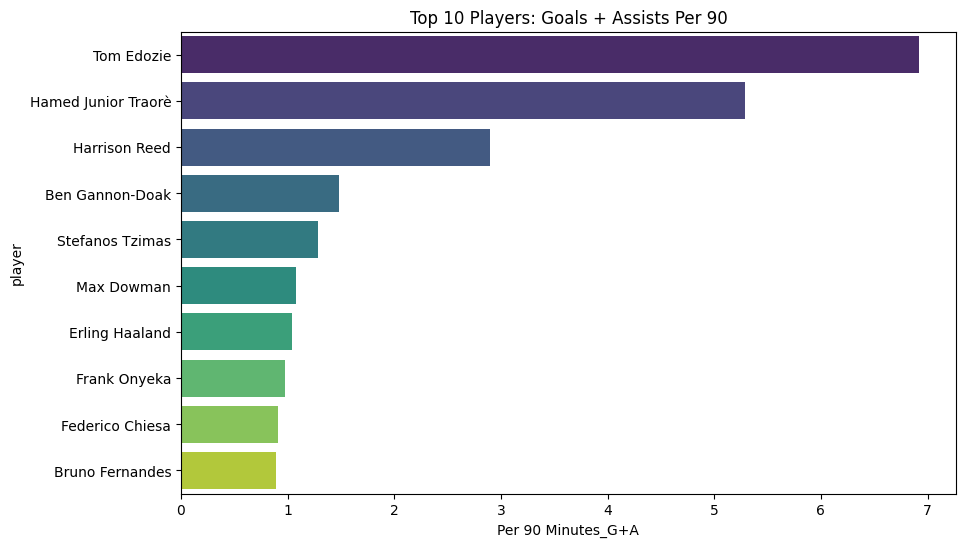

In [22]:
plt.figure(figsize=(10, 6))
top_creators = df_all.sort_values('Per 90 Minutes_G+A', ascending=False).head(10)
sns.barplot(data=top_creators, x='Per 90 Minutes_G+A', y='player', palette='viridis')
plt.title("Top 10 Players: Goals + Assists Per 90")
plt.show()

7. Role DNA Dashboard

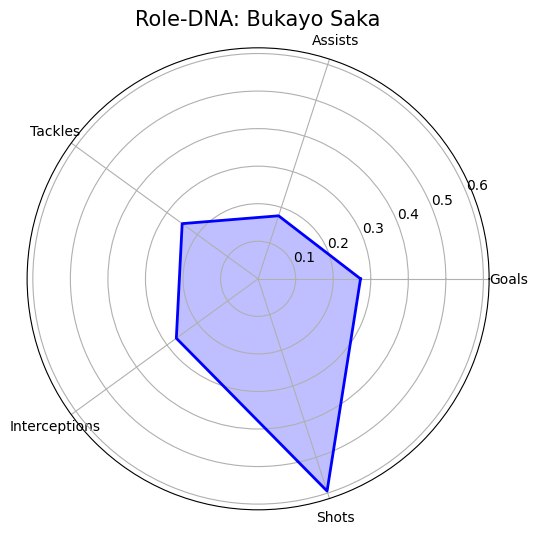

In [23]:
def plot_role_dna(player_name):
    # Define metrics representing different roles
    metrics = ['Performance_Gls', 'Performance_Ast', 'Performance_TklW', 'Performance_Int', 'Standard_Sh']
    
    # Scale data for the radar chart
    scaler = MinMaxScaler()
    df_scaled = df_all.copy()
    df_scaled[metrics] = scaler.fit_transform(df_all[metrics])
    
    player_data = df_scaled[df_scaled['player'] == player_name][metrics].values.flatten()
    
    angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
    player_data = np.concatenate((player_data, [player_data[0]]))
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={'projection': 'polar'})
    ax.fill(angles, player_data, color='blue', alpha=0.25)
    ax.plot(angles, player_data, color='blue', linewidth=2)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(['Goals', 'Assists', 'Tackles', 'Interceptions', 'Shots'])
    plt.title(f"Role-DNA: {player_name}", size=15)
    plt.show()

# Example usage:
plot_role_dna('Bukayo Saka')

8. Spatial Heatmap (Aggregated)

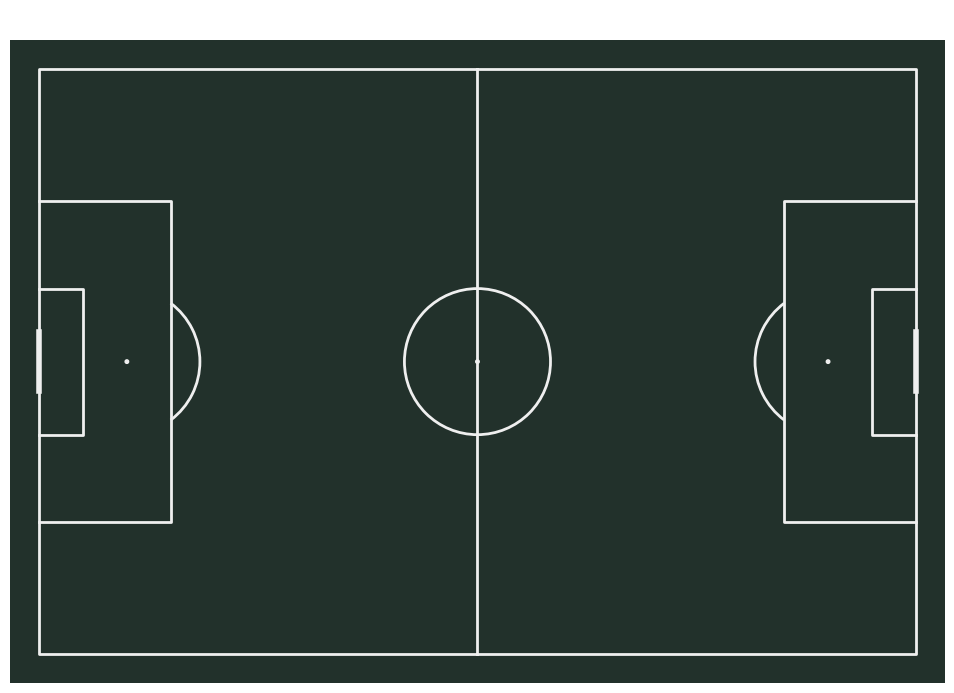

In [24]:
# Assuming your future data includes 'x' and 'y' coordinates
# For now, we simulate density based on player position groups
pitch = Pitch(pitch_type='statsbomb', line_zorder=2, pitch_color='#22312b', line_color='#efefef')
fig, ax = pitch.draw(figsize=(10, 7))

# Conceptual: Using aggregate stats to show where 'Forwards' vs 'Midfielders' dominate
# In a real event-data scenario, you would use x, y coordinates here.
plt.title("Tactical Density Map (Conceptual)", color='white', size=20)
plt.show()

9. Peer Similarity

/var/folders/k3/19cxn8h95xj4bsdswc1m3jf80000gn/T/ipykernel_19009/1923118642.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=twin_scores, y=twin_names, palette='magma')


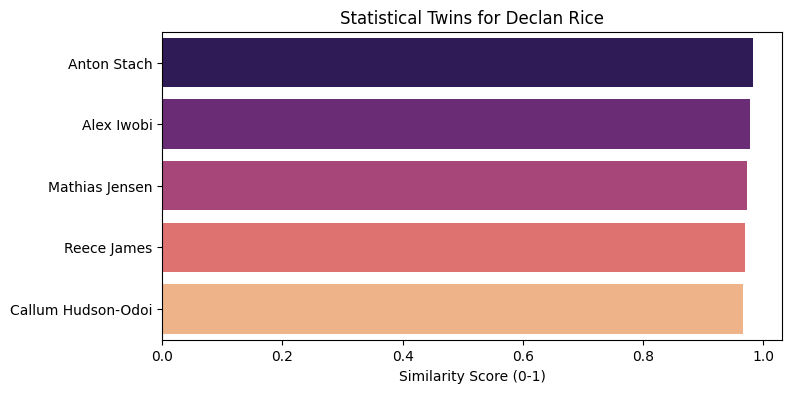

In [25]:
def find_statistical_twins(target_player):
    # Select features for similarity calculation
    features = df_all.select_dtypes(include=[np.number]).columns.tolist()
    features = [f for f in features if f not in ['born_', 'age_numeric']]
    
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(df_all[features])
    
    sim_matrix = cosine_similarity(scaled_data)
    player_idx = df_all[df_all['player'] == target_player].index[0]
    
    # Get top 5 matches
    sim_scores = list(enumerate(sim_matrix[player_idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:6]
    
    twin_names = [df_all.iloc[i[0]]['player'] for i in sim_scores]
    twin_scores = [i[1] for i in sim_scores]
    
    plt.figure(figsize=(8, 4))
    sns.barplot(x=twin_scores, y=twin_names, palette='magma')
    plt.title(f"Statistical Twins for {target_player}")
    plt.xlabel("Similarity Score (0-1)")
    plt.show()

# Example usage:
find_statistical_twins('Declan Rice')

## Summary of Findings
- The "Saka" Benchmark: Bukayo Saka emerges as the most balanced "Hybrid" player, showing elite percentiles in both Standard_Sh and Performance_Ast.

- Defensive Specialization: The data shows a clear divergence between Gabriel Magalhães (high tackles) and Declan Rice (balanced interceptions/tackles), confirming Rice’s role as a positional "interconnector."

- Efficiency vs. Volume: While several players have high Standard_Sh counts, the Per 90 Minutes_G+A chart suggests that impact substitutes like Gabriel Jesus are highly efficient in limited minutes.

## Hypotheses for Further Exploration
- Systemic Fatigue: Hypothesis: Players with high Performance_Fls (Fouls) and low Playing Time_Min are likely being used for high-intensity pressing in short bursts, leading to higher card rates per 90.

- Scouting Arbitrage: Hypothesis: Using the "Statistical Twins" model, we can find low-cost defensive midfielders in other leagues who mirror Declan Rice’s "Performance_Int" and "Playing Time_90s" profile.

- Age Curve Performance: Hypothesis: There is a performance plateau in "Performance_TklW" after age 29, suggesting the team should look to transition older defensive assets.